## PRÁCTICA 3: Aprendizaje por refuerzo

##### Importamos el entorno

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array", g=9.81)  # default g=10.0

##### Mostramos el entorno

Observación inicial: [-0.5787706   0.8154904  -0.02160932]


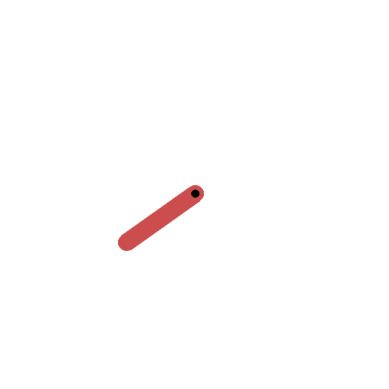

In [3]:
obs, _ = env.reset()

print("Observación inicial:", obs)

def muestra_entorno(env: gym.Env) -> None:
    plt.imshow(env.render())
    plt.axis('off')
    plt.show()

muestra_entorno(env)

##### Discretizamos las acciones

In [11]:
NUM_ACCIONES = 5
acciones = np.linspace(-2, 2, NUM_ACCIONES)  # 5 acciones discretas

##### Creamos la clase Estado

In [12]:
from collections import namedtuple

Estado = namedtuple('Estado', ['cos', 'sin', 'vel'])

def get_estado(obs):
    return Estado(obs[0], obs[1], obs[2])


##### Discretizamos los estados

In [13]:
NUM_INTERVALOS = 20

cos_intervalos = np.linspace(-1, 1, NUM_INTERVALOS)
sin_intervalos = np.linspace(-1, 1, NUM_INTERVALOS)
vel_intervalos = np.linspace(-8, 8, NUM_INTERVALOS)

In [14]:
def discretizar_estado(obs):
    cos_t, sin_t, vel = obs

    # la función np.digitize(valor, bins) asigna un valor a su intervalo correspondiente
    i = np.digitize(cos_t, cos_intervalos) - 1
    j = np.digitize(sin_t, sin_intervalos) - 1
    k = np.digitize(vel, vel_intervalos) - 1

    i = np.clip(i, 0, NUM_INTERVALOS-1)
    j = np.clip(j, 0, NUM_INTERVALOS-1)
    k = np.clip(k, 0, NUM_INTERVALOS-1)

    return (i, j, k)

In [15]:
obs, _ = env.reset()

estado = get_estado(obs)
estado_discreto = discretizar_estado(obs)

print("Estado continuo:", estado)
print("Estado discreto:", estado_discreto)

Estado continuo: Estado(cos=np.float32(-0.06855598), sin=np.float32(0.9976473), vel=np.float32(-0.8531886))
Estado discreto: (np.int64(8), np.int64(18), np.int64(8))


##### Creamos política aleatoria de prueba

In [16]:
politica_aleatoria = np.ones((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES)) / NUM_ACCIONES

In [35]:
def muestrea_politica(estado, politica):
    cos_bin, sin_bin, vel_bin = estado

    probs = politica[cos_bin, sin_bin, vel_bin]

    np.testing.assert_almost_equal(np.sum(probs), 1.0, err_msg='La política para un estado siempre debe sumar 1')

    accion_idx = np.random.choice(NUM_ACCIONES, p=probs)

    return accion_idx

obs, _ = env.reset()
estado = discretizar_estado(obs)

accion_idx = muestrea_politica(estado, politica_aleatoria)
accion = np.array([acciones[accion_idx]])

print("Estado:", estado)
print("Acción escogida:", accion)

obs, reward, terminated, truncated, info = env.step(accion)

print("Obs:", obs)
print("Reward:", reward)

Estado: (np.int64(0), np.int64(12), np.int64(8))
Acción escogida: [0.]
Obs: [-0.9447995   0.32764912 -0.3971303 ]
Reward: -8.034500306779945


##### Simulamos episodio

In [ ]:
def simula_episodio(politica: np.ndarray, muestra_renders: bool = False, imprime: bool = False):

    obs, _ = env.reset()
    estado_actual = discretizar_estado(obs)

    completado = False
    contador = 0
    retorno = 0
    recorrido = []

    MAX_STEPS = 200  # Pendulum no termina solo

    while not completado and contador < MAX_STEPS:

        accion_idx = muestrea_politica(estado_actual, politica)
        accion = np.array([acciones[accion_idx]])
        obs, recompensa, terminated, truncated, info = env.step(accion)

        nuevo_estado = discretizar_estado(obs)
        recorrido.append((estado_actual, accion_idx, recompensa))
        retorno += recompensa
        contador += 1

        estado_actual = nuevo_estado
        completado = terminated or truncated or (contador >= MAX_STEPS)

        if imprime:
            print("Paso:", contador)
            print("Acción idx:", accion_idx)
            print("Acción real:", accion)
            print("Estado:", estado_actual)
            print("Recompensa:", recompensa)
            print()

        if muestra_renders:
            muestra_entorno(env)

    return retorno, contador, recorrido

retorno, num_pasos, recorrido = simula_episodio(politica_aleatoria, muestra_renders=False, imprime=False)
print(f'Simulado un episodio con retorno = {retorno} y pasos = {num_pasos}')

retorno, num_pasos, recorrido = simula_episodio(politica_aleatoria, False, True)

print('Recorrido:', recorrido)

Simulado un episodio con retorno = -931.5127818062206 y pasos = 200
Paso: 1
Acción idx: 4
Acción real: [2.]
Estado: (np.int64(2), np.int64(16), np.int64(11))
Recompensa: -5.205766165417868

Paso: 2
Acción idx: 0
Acción real: [-2.]
Estado: (np.int64(2), np.int64(15), np.int64(11))
Recompensa: -5.848554967408879

Paso: 3
Acción idx: 4
Acción real: [2.]
Estado: (np.int64(1), np.int64(14), np.int64(12))
Recompensa: -6.4128673648050665

Paso: 4
Acción idx: 0
Acción real: [-2.]
Estado: (np.int64(0), np.int64(13), np.int64(12))
Recompensa: -7.476978354349821

Paso: 5
Acción idx: 4
Acción real: [2.]
Estado: (np.int64(0), np.int64(11), np.int64(13))
Recompensa: -8.284612542295113

Paso: 6
Acción idx: 3
Acción real: [1.]
Estado: (np.int64(0), np.int64(9), np.int64(13))
Recompensa: -9.626496733532012

Paso: 7
Acción idx: 4
Acción real: [2.]
Estado: (np.int64(0), np.int64(8), np.int64(14))
Recompensa: -10.99267674882231

Paso: 8
Acción idx: 3
Acción real: [1.]
Estado: (np.int64(0), np.int64(6), np

##### Comprobación del rendimiento de la política

0 - Simulado un episodio con retorno -1543.413937580746 y número de pasos = (200)
1 - Simulado un episodio con retorno -1096.619913499371 y número de pasos = (200)
2 - Simulado un episodio con retorno -1650.8642973604703 y número de pasos = (200)
3 - Simulado un episodio con retorno -1371.5997720564246 y número de pasos = (200)
4 - Simulado un episodio con retorno -1571.267424913423 y número de pasos = (200)
5 - Simulado un episodio con retorno -1008.3354614769739 y número de pasos = (200)
6 - Simulado un episodio con retorno -966.0941025679411 y número de pasos = (200)
7 - Simulado un episodio con retorno -1377.2826707218196 y número de pasos = (200)
8 - Simulado un episodio con retorno -1673.7696497684967 y número de pasos = (200)
9 - Simulado un episodio con retorno -1172.899336427637 y número de pasos = (200)
10 - Simulado un episodio con retorno -1002.0121019669006 y número de pasos = (200)
11 - Simulado un episodio con retorno -1710.0075856400235 y número de pasos = (200)
12 - Si

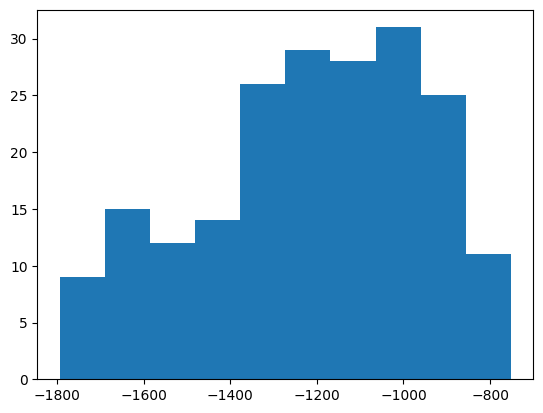

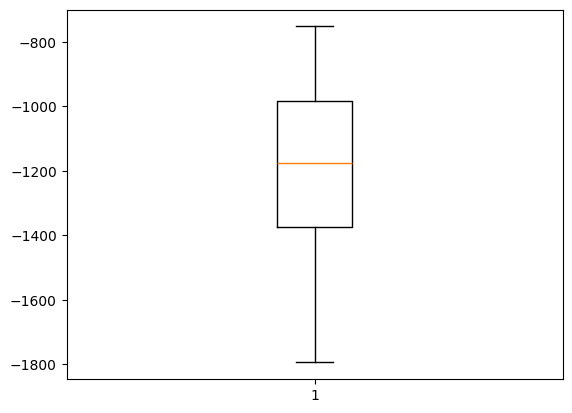

En cada paso se ha obtenido de media un retorno de  -1204.9690670327116 (+- 262.93542557547624 )
El retorno más pequeño fue -1793.7991427143334 y el retorno más grande fue -752.0560669305477


In [40]:
def comprueba_politica(politica:np.ndarray, imprime:bool = False) -> None:
    episodios_retornos = []
    for i in range(200):
        retorno, num_pasos, recorrido = simula_episodio(politica, False, imprime)
        episodios_retornos.append(retorno)
        print(f'{i} - Simulado un episodio con retorno {retorno} y número de pasos = ({num_pasos})')

    # histograma para los retornos
    plt.hist(episodios_retornos)
    plt.show()

    # diagrama de caja
    plt.boxplot(episodios_retornos)
    plt.show()

    # estadísticas de media y desviación típica
    print('En cada paso se ha obtenido de media un retorno de ',np.mean(episodios_retornos),'(+-',np.std(episodios_retornos),')')
    print('El retorno más pequeño fue',np.min(episodios_retornos),'y el retorno más grande fue',np.max(episodios_retornos))

comprueba_politica(politica_aleatoria)